# Seventeen players, or one player seventeen times?

Every fit in this project has been **per player and independent**. Notebook 21
fitted each professional separately, notebook 24 did it again for two more
families, notebook 25 for a third, and nothing any player's darts said was ever
allowed to inform anyone else's estimate.

That is the right default -- it is the only way to *find out* that players differ
-- but it is not obviously the best estimator. The alternative says players are
drawn from a population:

$$\hat\theta_p \sim N(\theta_p,\ s_p^2), \qquad \theta_p \sim N(\mu,\ \tau^2)$$

and estimates $\mu$ and $\tau$ alongside the players. $\tau$ is the interesting
one: how much players differ *after* subtracting the noise in measuring them. At
$\tau = 0$ everyone is the same and the best estimate for anybody is the grand
mean; at $\tau \to \infty$ nothing is shared. In between, each player's estimate
is pulled toward the population by an amount set by how badly they were measured.

Notebook 25 is why this is worth asking here rather than in the abstract. A
player's lean has a split-half reliability of 0.45, and a parameter that badly
measured is exactly where partial pooling is supposed to earn its keep.

Three estimators, one held-out comparison: **no pooling**, **partial pooling**,
**complete pooling**. The last one is not a straw man -- it is what you get by
treating "a professional" as a single throw model, which is what the rest of the
project's ability bands do.

And then a fourth, in section 5, once the first three have said something the
middle one cannot be trusted about: the hierarchical model fitted as itself,
rather than to seventeen summaries of it.

The sketch above is the scalar cartoon of all four. Section 1 writes the model
down properly, because the four estimators differ only in which approximation
they make to one integral, and the whole result turns out to be about that.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.hierarchical import (heterogeneity, random_effects, random_effects_mv,
                                shrink)
from darts.throw_families import FAMILIES, FamilyVisitModel, RadialBedGrid

PARAMS = ['log_scale', 'bias_x', 'log_nu_minus_2', 'e1', 'e2',
          'logit_s_hit', 'logit_s_miss']
RES = os.path.join(module_path, 'results', 'heterogeneity')
MODEL = FamilyVisitModel(FAMILIES['tilted-t'], RadialBedGrid(512))


def load(path):
    df = pd.read_csv(os.path.join(path, 'players.csv'))
    z = np.load(os.path.join(path, 'visits.npz'), allow_pickle=True)
    theta = np.stack([z[f'{i}_theta'] for i in range(len(df))])
    covs = np.stack([z[f'{i}_cov'] for i in range(len(df))])
    return df, z, theta, covs


FITS, Z, THETA, COVS = load(RES)
OK = np.array([np.isfinite(c).all() for c in COVS])
ll = lambda th, i: MODEL.log_likelihood(th, Z[f'{i}_b_te'], Z[f'{i}_h_te'])
BASE = np.array([ll(THETA[i], i) for i in range(len(FITS))])
N = FITS.n_test.values
print(f'{len(FITS)} players, {OK.sum()} with a full covariance, '
      f'{N.sum():,} held-out visits')

17 players, 12 with a full covariance, 5,469 held-out visits


## 1 · The model, and the three approximations of it

Everything below is a way of *not* doing one integral, so it is worth writing the
integral down first.

### The two levels

Each player $p$ has a parameter vector $\theta_p \in \mathbb{R}^7$ — the log core
scale, the horizontal bias, $\log(\nu-2)$, the two ellipse coordinates
$(e_1, e_2)$, and the two dependence logits. Their visits $y_p$ give a
log-likelihood $L_p(\theta) = \log P(y_p \mid \theta)$, which is the only thing
their own darts have to say. The hierarchical model adds a second level above it:

$$\theta_p \sim N(\mu,\ T), \qquad y_p \mid \theta_p \sim \text{the visit model}$$

$\mu$ is what a professional looks like on average and $T$ is how much
professionals differ — a full $7\times 7$ covariance, so "differ" includes
*differing together*, which section 4 shows is most of it.

### What is actually being estimated

$\mu$ and $T$. **Not** the $\theta_p$. That distinction is not pedantry: there
are $17 \times 7 = 119$ player parameters against 35 population ones, and the
count of the former grows with the number of players. Maximising over both at
once is the Neyman–Scott problem and does not give a consistent estimate of $T$ —
it would read the noise in locating 119 parameters as evidence that players
differ. The player effects have to be **integrated out**:

$$\mathcal{L}(\mu, T) \;=\; \sum_p \log \int e^{L_p(\theta)}\, N(\theta;\mu,T)\, d\theta$$

That integral has no closed form, because $L_p$ is a sum over visits of the log
of a mixture over three darts on a 512-pixel board. Three estimators, three ways
of approximating it.

### Approximation 1 — expand $L_p$ about its own maximum (two-stage)

Take a quadratic expansion of each player's likelihood at their own fit
$\hat\theta_p$:

$$L_p(\theta) \approx L_p(\hat\theta_p) - \tfrac{1}{2}(\theta - \hat\theta_p)^{\!\top} V_p^{-1} (\theta - \hat\theta_p)$$

with $V_p$ the inverse observed information. The integral is then Gaussian and
everything is closed form. The marginal collapses to the classical meta-analysis
model,

$$\hat\theta_p \mid \mu, T \;\sim\; N(\mu,\ V_p + T)$$

and each player's posterior is

$$C_p = (V_p^{-1} + T^{-1})^{-1}, \qquad m_p = C_p\left(V_p^{-1}\hat\theta_p + T^{-1}\mu\right)$$

which in one dimension is the familiar shrinkage
$m = w\,\hat\theta + (1-w)\,\mu$ with $w = \tau^2/(\tau^2 + s^2)$ — a player's own
answer, pulled toward the population by an amount set by how badly they were
measured.

It assumes three things, and all three bite here:

* **$L_p$ is quadratic.** It is not. $\log(\nu-2)$ is the worst offender — the
  likelihood in that direction is flat over a wide range and then falls off a
  cliff at the $\nu > 2$ clip.
* **$V_p$ is known**, rather than itself estimated from the same 200–650 visits
  that produced $\hat\theta_p$. Seven parameters from a few hundred visits is not
  a regime where the curvature is a known constant.
* **$\hat\theta_p$ and $V_p$ exist.** For five of these seventeen players on one
  split and six on the other, $\nu$ runs to the clip, $L_p$ is flat in that
  direction, the information matrix is singular, and there is simply nothing to
  hand to the second stage. Those players get dropped.

### Approximation 2 — force $T$ diagonal (coordinate-wise)

Running the scalar formula on one parameter at a time is exactly the assumption
that $T$ and every $V_p$ are diagonal. Geometrically it pulls each coordinate
toward its own mean, which moves the *vector* parallel to the axes. If the
players lie along a ridge — and section 4 measures the core scale against
elongation at $-0.745$ — then moving along the axes takes the estimate off the
ridge, to a place no player is. This is a strictly stronger approximation than
the first, layered on top of it.

### Approximation 3 — expand the whole integrand (the full joint)

Do not expand $L_p$ on its own. Expand the thing actually being integrated.
Write the penalised objective

$$h_p(\theta) \;=\; L_p(\theta) + \log N(\theta;\mu,T)$$

and let $\theta^*_p = \arg\max h_p$ be its mode and
$H_p = -\nabla^2 h_p(\theta^*_p) = -\nabla^2 L_p(\theta^*_p) + T^{-1}$ its
curvature. Laplace's approximation is then

$$\int e^{L_p}N(\theta;\mu,T)\,d\theta \;\approx\; e^{h_p(\theta^*_p)}\,(2\pi)^{k/2}\,|H_p|^{-1/2}$$

and the fit is EM with $q_p = N(\theta^*_p,\ C_p)$, $C_p = H_p^{-1}$:

$$\textbf{E step:}\quad \theta^*_p,\ C_p \quad\text{for each player}$$

$$\textbf{M step:}\quad \mu = \frac{1}{n}\sum_p \theta^*_p, \qquad T = \underbrace{\frac{1}{n}\sum_p C_p}_{\text{noise in locating a mode}} + \underbrace{\frac{1}{n}\sum_p (\theta^*_p - \mu)(\theta^*_p - \mu)^{\!\top}}_{\text{spread between modes}}$$

The M step is the maximum-likelihood Gaussian fitted to the posterior moments,
using $E_q[(\theta-\mu)(\theta-\mu)^{\!\top}] = C_p + (m_p-\mu)(m_p-\mu)^{\!\top}$.
The first term is the whole point of a hierarchical model and the reason $T$ is
not simply the sample covariance of the fitted players: that would count the
noise in locating each player as if it were evidence that players differ.

### Why this one is different in kind, not degree

**It cannot fail at a boundary.** $H_p = -\nabla^2 L_p + T^{-1}$ is positive
definite whenever $T$ is, *whatever* $L_p$ does. A player whose likelihood is
flat in the $\nu$ direction contributes no curvature there and simply inherits
$T^{-1}$; the population places their $\nu$ instead of the constraint doing it.
Two-stage has no such term — it needs $(-\nabla^2 L_p)^{-1}$ to exist on its own.

**And the mode moves.** $\theta^*_p$ depends on $(\mu, T)$ and is re-found at
every iteration; $\hat\theta_p$ does not depend on them at all. So two-stage can
only *average* a player's fixed answer with the population afterwards, while the
joint fit changes what the player's own darts are taken to say. The two coincide
exactly when $L_p$ is quadratic — which is the test the implementation is
validated against, and nothing like the real case.

### The three estimators are one family

$T \to 0$ is complete pooling: every player is $\mu$. $T \to \infty$ is no
pooling: every player is their own fit. Everything in this notebook is a point in
between, and the argument is only ever about *where*. That is why held-out legs
are the arbiter — all three are the same model at different $T$, so likelihood on
data none of them saw is a fair comparison rather than a comparison of model
complexity.

Two honest caveats before the numbers.

**The scalar fits use REML, the joint fit uses ML.** Maximum likelihood is biased
downward for a variance component when $\mu$ is estimated from the same data,
because it does not pay for the degree of freedom that costs; REML corrects it,
and `random_effects` uses it. The Laplace-EM above is plain ML, so at $n = 17$
its $T$ is biased a little small — which shrinks players slightly too hard, i.e.
it is a bias *against* the estimator that ends up winning.

**Laplace is exact only asymptotically in each player's own visit count.** Its
error is $O(n_p^{-1})$ per player, and $n_p$ here is 204 to 650. So the joint fit
is not the truth either; it is one approximation fewer.

The cell below checks the two M-step conditions on the converged fit, and then
shows what the second one is *for*. Neither obvious answer is $T$. The spread of
the players' **own fits** is far too big — trace 214 against 7.4, and
$\log(\nu-2)$ alone has a standard deviation of 12.7 because the clipped players
sit wherever the constraint left them. The spread of the **penalised modes** is
slightly too small, at 6.5, because those modes have already been shrunk toward
the population. $T$ is the second plus the average posterior variance,
which puts back exactly the shrinkage that was applied — a correction worth 11.7%
of $T$ here.

In [2]:
# The two M-step conditions, checked on the converged fit rather than assumed --
# they are what "converged" means for this model.
J = np.load(os.path.join(RES, 'joint.npz'), allow_pickle=True)
mu_j, T_j, modes, C_j = J['mu'], J['T'], J['theta'], J['cov']
n_j = len(modes)
d_j = modes - modes.mean(axis=0)
scatter = d_j.T @ d_j / n_j

print(f'mu = mean of the penalised modes    max discrepancy '
      f'{np.abs(mu_j - modes.mean(axis=0)).max():.1e}')
print(f'T  = mean(C) + scatter(modes)       max discrepancy '
      f'{np.abs(T_j - (C_j.mean(axis=0) + scatter)).max():.1e} '
      f'({np.abs(T_j - (C_j.mean(axis=0) + scatter)).max() / np.abs(T_j).max():.2%})')

# and what the second condition is *for*: neither of the two obvious answers is T
raw = np.stack([Z[f'{i}_theta'] for i in range(len(FITS))])
print(f'\n{"":<16}{"sd of the":>12}{"sd of the":>11}{"":>10}')
print(f'{"":<16}{"own fits":>12}{"modes":>11}{"tau in T":>10}')
for j, name in enumerate(PARAMS):
    print(f'{name:<16}{raw[:, j].std(ddof=1):>12.3f}{np.sqrt(scatter[j, j]):>11.3f}'
          f'{np.sqrt(T_j[j, j]):>10.3f}')
print(f'{"(trace)":<16}{np.trace(np.cov(raw.T)):>12.1f}{np.trace(scatter):>11.2f}'
      f'{np.trace(T_j):>10.2f}')


mu = mean of the penalised modes    max discrepancy 2.1e-03
T  = mean(C) + scatter(modes)       max discrepancy 7.6e-03 (0.16%)

                   sd of the  sd of the          
                    own fits      modes  tau in T
log_scale              0.129      0.107     0.116
bias_x                 2.436      2.052     2.172
log_nu_minus_2        12.650      1.212     1.314
e1                     0.210      0.156     0.167
e2                     0.183      0.115     0.132
logit_s_hit            6.910      0.727     0.781
logit_s_miss           0.566      0.524     0.537
(trace)                214.1       6.53      7.40


## 2 · Before pooling anything: do they differ?

If $I^2$ is near zero the players are indistinguishable, the shrinkage will be
total, and the "hierarchical model" is complete pooling wearing a hat. So this is
the question to ask first, parameter by parameter.

One number to carry into reading it. The tests for `darts.hierarchical` measure
the power of this exact test at this exact sample size: seventeen players give
**about 62% power against a moderate $\tau = 0.3$**, and hold the nominal 5% size
under the null. So a null result here means "no large differences", not "no
differences".

In [3]:
rows = []
for j, name in enumerate(PARAMS):
    se = FITS['se_' + name].values
    m = np.isfinite(se)
    h = heterogeneity(THETA[m, j], se[m])
    r = random_effects(THETA[m, j], se[m])
    s = shrink(THETA[m, j], se[m], r['mu'], r['tau'])
    rows.append(dict(parameter=name, n=int(m.sum()), mu=r['mu'], tau=r['tau'],
                     I2=h['I2'], Q_p=h['p'], mean_shrinkage=1 - s['weight'].mean()))
het = pd.DataFrame(rows)
print('how much players differ, parameter by parameter:')
print(het.round(3).to_string(index=False))
print('\nplayers differ significantly on %d of %d parameters.'
      % ((het.Q_p < 0.05).sum(), len(het)))

how much players differ, parameter by parameter:
     parameter  n     mu   tau    I2   Q_p  mean_shrinkage
     log_scale 16  1.662 0.077 0.526 0.007           0.533
        bias_x 16 -1.292 2.231 0.841 0.000           0.150
log_nu_minus_2 12 -0.145 0.732 0.601 0.004           0.422
            e1 16  0.039 0.186 0.806 0.000           0.177
            e2 16 -0.011 0.091 0.355 0.079           0.664
   logit_s_hit 16 -2.950 0.685 0.828 0.000           0.216
  logit_s_miss 16 -0.934 0.556 0.954 0.000           0.047

players differ significantly on 6 of 7 parameters.


They differ, on six of the seven.

$I^2$ runs from 0.53 to 0.95 -- most of the observed spread between players is
real, not measurement noise. The exception is $e_2$, the lean, at $I^2 = 0.36$ and
$p = 0.079$: notebook 25 found the same thing and it fails to replicate on a
second split, so it belongs in the "no large differences" box rather than the
"they are the same" one.

Note which parameter gets shrunk hardest. It is $e_2$, at 0.66 -- the one with
the least evidence of real variation. That is the estimator doing exactly what it
is supposed to: pull hardest where the differences look most like noise. The
question is whether pulling helps.

## 3 · The comparison

Each player's parameters are fitted on their training legs; the shrinkage uses
only those; every estimator is scored on the same held-out legs.

In [4]:
def coordinatewise(df, theta):
    out = theta.copy()
    for j, name in enumerate(PARAMS):
        se = df['se_' + name].values
        m = np.isfinite(se)
        if m.sum() < 8:
            continue
        r = random_effects(theta[m, j], se[m])
        out[m, j] = shrink(theta[m, j], se[m], r['mu'], r['tau'])['posterior_mean']
    return out


COORD = coordinatewise(FITS, THETA)
POOLED = np.tile(Z['pooled_theta'], (len(FITS), 1))
scores = {}
for label, th in (('no pooling', THETA), ('partial pooling', COORD),
                  ('complete pooling', POOLED)):
    tot = sum(ll(th[i], i) for i in range(len(FITS)))
    scores[label] = tot
    print(f'{label:<20} held-out logL {tot:10.1f}   per visit {tot / N.sum():.4f}'
          f'   {tot - BASE.sum():+8.1f} vs no pooling')

no pooling           held-out logL   -22473.5   per visit -4.1093       -0.0 vs no pooling


partial pooling      held-out logL   -22513.7   per visit -4.1166      -40.2 vs no pooling


complete pooling     held-out logL   -22838.1   per visit -4.1759     -364.5 vs no pooling


**No pooling wins.** Partial pooling is 40 log units behind it, complete pooling
365 behind. (Both of those are two-stage estimators, and section 5 revisits that.)

The second of those is the reassuring one and is worth saying first: treating all
seventeen professionals as one throw model costs **0.067 a visit**, which is a
tenth of the entire Gaussian-to-Student-t improvement notebook 21 measured. Real
players are not interchangeable, and any result that treats "a professional" as a
single parameter set is paying for it.

The first is the surprise. Shrinkage is supposed to help, and here it hurts.

In [5]:
print('shrinking one parameter at a time, to see where the loss comes from:')
for j, name in enumerate(PARAMS):
    se = FITS['se_' + name].values
    m = np.isfinite(se)
    r = random_effects(THETA[m, j], se[m])
    s = shrink(THETA[m, j], se[m], r['mu'], r['tau'])
    th = THETA.copy()
    th[m, j] = s['posterior_mean']
    d = np.array([ll(th[i], i) for i in range(len(FITS))]) - BASE
    print(f'   {name:<16} tau {r["tau"]:.3f}  shrunk {1 - s["weight"].mean():.2f}'
          f'  ->  {d.sum():+7.1f} log units')

d = np.array([ll(COORD[i], i) for i in range(len(FITS))]) - BASE
order = np.argsort(FITS.n_train.values)
print('\nand by how much data the player has:')
for lab, idx in (('smallest 6', order[:6]), ('middle 5', order[6:11]),
                 ('largest 6', order[11:])):
    print(f'   {lab:<12} n_train {FITS.n_train.values[idx].min():4d}-'
          f'{FITS.n_train.values[idx].max():4d}   {d[idx].sum():+7.1f} log units '
          f'({d[idx].sum() / N[idx].sum():+.4f} a visit)')

shrinking one parameter at a time, to see where the loss comes from:


   log_scale        tau 0.077  shrunk 0.53  ->    -32.8 log units


   bias_x           tau 2.231  shrunk 0.15  ->     +0.6 log units


   log_nu_minus_2   tau 0.732  shrunk 0.42  ->     -2.8 log units


   e1               tau 0.186  shrunk 0.18  ->     -1.4 log units


   e2               tau 0.091  shrunk 0.66  ->     -6.9 log units


   logit_s_hit      tau 0.685  shrunk 0.22  ->     -5.8 log units


   logit_s_miss     tau 0.556  shrunk 0.05  ->     -0.6 log units



and by how much data the player has:
   smallest 6   n_train  204- 263     -30.6 log units (-0.0215 a visit)
   middle 5     n_train  264- 307      +2.6 log units (+0.0018 a visit)
   largest 6    n_train  338- 650     -12.2 log units (-0.0046 a visit)


Two things in that, and the second is the diagnostic.

Almost all the damage is **one parameter**: the core scale, at $-32.8$ of the
$-40$ log units. It is the most precisely measured parameter of the seven and it
is shrunk the hardest of all except $e_2$ -- 53%. A small $\tau$ next to small
$s_p$ still means the players are genuinely apart; shrinking them together
discards real signal.

And it hurts **most on the players with the least data** -- $-0.0215$ a visit for
the smallest six against $-0.0046$ for the largest six. That is backwards. The
entire point of shrinkage is that badly measured units benefit most, and here they
suffer most. Something is wrong with the estimator, not merely unhelpful.

## 4 · The diagnosis, and the fix that does not fix it

Shrinking each coordinate toward its own mean quietly assumes the parameters are
independent. Across these players they are conspicuously not.

In [6]:
C = np.corrcoef(THETA.T)
print('correlation of the per-player estimates:')
print(pd.DataFrame(np.round(C, 2), index=PARAMS,
                   columns=[p[:9] for p in PARAMS]).to_string())
print(f'\nthe core-scale / nu ridge notebook 21 found at +0.62:  '
      f'r = {C[0, 2]:+.3f}')
print(f'core scale against elongation:                        r = {C[0, 3]:+.3f}')
print('\nso pulling each coordinate toward its own average drags the whole vector')
print('off the ridge the players actually lie on -- to a place no player is.')

correlation of the per-player estimates:
                log_scale  bias_x  log_nu_mi    e1    e2  logit_s_h  logit_s_m
log_scale            1.00    0.73       0.52 -0.74 -0.15      -0.15       0.55
bias_x               0.73    1.00       0.46 -0.53  0.09       0.12       0.55
log_nu_minus_2       0.52    0.46       1.00 -0.59  0.13      -0.14       0.30
e1                  -0.74   -0.53      -0.59  1.00  0.02       0.18      -0.49
e2                  -0.15    0.09       0.13  0.02  1.00      -0.46      -0.43
logit_s_hit         -0.15    0.12      -0.14  0.18 -0.46       1.00       0.22
logit_s_miss         0.55    0.55       0.30 -0.49 -0.43       0.22       1.00

the core-scale / nu ridge notebook 21 found at +0.62:  r = +0.521
core scale against elongation:                        r = -0.745

so pulling each coordinate toward its own average drags the whole vector
off the ridge the players actually lie on -- to a place no player is.


In [7]:
def joint(theta, covs, ok, sel):
    sel = np.array(sel)
    mv = random_effects_mv(theta[ok][:, sel], covs[ok][:, sel][:, :, sel])
    out = theta.copy()
    out[np.ix_(ok, sel)] = mv['posterior_mean']
    return out


variants = {'joint, all 7 parameters': [0, 1, 2, 3, 4, 5, 6],
            'joint, the throw only (scale, nu, e1, e2)': [0, 2, 3, 4],
            'joint, the shape only (e1, e2)': [3, 4],
            'joint, scale and nu (the known ridge)': [0, 2]}
print('taking the parameters together instead of one at a time:')
print(f'   {"partial, coordinate-wise":<44} '
      f'{scores["partial pooling"] - BASE.sum():+8.1f} log units')
for label, sel in variants.items():
    th = joint(THETA, COVS, OK, sel)
    tot = sum(ll(th[i], i) for i in range(len(FITS)))
    print(f'   {label:<44} {tot - BASE.sum():+8.1f} log units '
          f'({(tot - BASE.sum()) / N.sum():+.4f} a visit)')

taking the parameters together instead of one at a time:
   partial, coordinate-wise                        -40.2 log units


   joint, all 7 parameters                          -7.8 log units (-0.0014 a visit)


   joint, the throw only (scale, nu, e1, e2)       +13.2 log units (+0.0024 a visit)


   joint, the shape only (e1, e2)                  -20.6 log units (-0.0038 a visit)


   joint, scale and nu (the known ridge)           -15.4 log units (-0.0028 a visit)


There it is: the core scale and the elongation correlate at $-0.745$ across
players, and the core scale with $\log(\nu-2)$ at $+0.521$ -- notebook 21's ridge,
recovered independently.

Taking the parameters together instead of one at a time recovers most of the loss:
$-40.2$ becomes $-7.8$, and the perverse damage to the smallest players nearly
vanishes. So the diagnosis was right. Coordinate-wise shrinkage moves each
parameter toward its own average and thereby moves the *vector* off the ridge the
players lie on, landing it somewhere no player is.

And one variant comes out **positive**: shrinking only the four throw parameters
gains $+13.2$ log units over fitting every player alone.

### One of those is positive. Is it real?

It was found by trying five variants and reading the held-out number, which is
selection on the test set -- the thing held-out likelihood exists to prevent. The
only way to know is a split that was never looked at, so the whole pipeline was
re-run on a second random division of the same legs.

In [8]:
DF1, Z1, TH1, CV1 = load(os.path.join(RES, 'seed1'))
OK1 = np.array([np.isfinite(c).all() for c in CV1])
ll1 = lambda th, i: MODEL.log_likelihood(th, Z1[f'{i}_b_te'], Z1[f'{i}_h_te'])
base1 = sum(ll1(TH1[i], i) for i in range(len(DF1)))
n1 = DF1.n_test.sum()

print(f'{"estimator":<44} {"seed 0":>14} {"seed 1":>14}')
print(f'{"(where the variants were explored)":<44} {"":>14} {"(never looked at)":>14}')
rows = [('partial, coordinate-wise',
         scores['partial pooling'] - BASE.sum(),
         sum(ll1(coordinatewise(DF1, TH1)[i], i) for i in range(len(DF1))) - base1)]
for label, sel in (('joint, all 7 parameters', [0, 1, 2, 3, 4, 5, 6]),
                   ('joint, the throw only (scale, nu, e1, e2)', [0, 2, 3, 4])):
    a = sum(ll(joint(THETA, COVS, OK, sel)[i], i) for i in range(len(FITS))) - BASE.sum()
    b = sum(ll1(joint(TH1, CV1, OK1, sel)[i], i) for i in range(len(DF1))) - base1
    rows.append((label, a, b))
rows.append(('complete pooling',
             scores['complete pooling'] - BASE.sum(),
             sum(ll1(np.tile(Z1['pooled_theta'], (len(DF1), 1))[i], i)
                 for i in range(len(DF1))) - base1))
for label, a, b in rows:
    print(f'{label:<44} {a:>+14.1f} {b:>+14.1f}')
print('\n(log units against no pooling on that same split)')

estimator                                            seed 0         seed 1
(where the variants were explored)                          (never looked at)


partial, coordinate-wise                              -40.2          -89.4
joint, all 7 parameters                                -7.8          -23.3
joint, the throw only (scale, nu, e1, e2)             +13.2          -20.1
complete pooling                                     -364.5         -357.7

(log units against no pooling on that same split)


**It does not replicate.** On a split that was never looked at, the same
estimator gives $-20.1$.

So the $+13.2$ was selection. Five variants were tried, the held-out number was
read for each, and the best was reported -- which is exactly the failure mode
held-out likelihood is supposed to prevent, and it does not prevent it once the
held-out set is used to choose among models. The confirmation run cost fifteen
minutes and turned a finding into an artefact.

Everything else replicates in sign and grows in size: coordinate-wise $-40$ then
$-89$, joint $-8$ then $-23$, complete pooling $-365$ then $-358$. On two
independent splits, **no two-stage variant of partial pooling beats fitting each
player alone.**

Two-stage is the qualifier that matters, and section 5 is about earning it. Every
estimator to this point collapses each player to a maximum and a curvature before
the population ever sees them, and the losses shrink in a suspiciously orderly way
as that approximation is weakened -- $-40$, then $-8$. It is worth asking what is
left when it is removed altogether.

## 5 · Every estimator so far is an approximation. Is that what is costing us?

Every estimator above is **approximation 1**, and the coordinate-wise one is
approximation 2 on top of it. Each player's likelihood was collapsed to a maximum
and a curvature before the population ever saw them, and section 1 named what
that costs. Both costs have now been paid in front of us rather than in theory:

**Five players were thrown away** -- the ones whose $\nu$ ran to the clip, with no
covariance to hand over. The joint variants above ran on twelve of the seventeen.

**And the modes could not move.** Two-stage shrinkage averages a player's fixed
answer with the population's after the fact. It never re-asks what their own
darts would say if the population were taken seriously.

So run approximation 3 -- Laplace at the penalised mode, fitted by the EM of
section 1 -- and see what is left.

In [9]:
JT = np.load(os.path.join(RES, 'joint.npz'), allow_pickle=True)
JT1 = np.load(os.path.join(RES, 'seed1', 'joint.npz'), allow_pickle=True)
gain = lambda J: J['test_ll'].sum() - J['base_test_ll'].sum()

print(f'{"":<44} {"seed 0":>14} {"seed 1":>14}')
for label, a, b in rows:
    print(f'{label:<44} {a:>+14.1f} {b:>+14.1f}')
print(f'{"full joint (Laplace-EM, all 17 players)":<44} '
      f'{gain(JT):>+14.1f} {gain(JT1):>+14.1f}')
print('\n(log units against no pooling on that same split)')
print(f'\nplayers used: two-stage joint {OK.sum()} / {len(FITS)}, '
      f'full joint {len(JT["theta"])} / {len(FITS)}')

                                                     seed 0         seed 1
partial, coordinate-wise                              -40.2          -89.4
joint, all 7 parameters                                -7.8          -23.3
joint, the throw only (scale, nu, e1, e2)             +13.2          -20.1
complete pooling                                     -364.5         -357.7
full joint (Laplace-EM, all 17 players)                +4.1          +12.2

(log units against no pooling on that same split)

players used: two-stage joint 12 / 17, full joint 17 / 17


**The approximation was most of the problem.** Coordinate-wise pooling lost 40
and 89 log units; the two-stage joint fit lost 8 and 23; fitting the model itself
**gains 4.1 and 12.2**.

That is the first estimator in this notebook to land on the right side of zero on
*both* splits, and the ordering is a clean story. Each time an approximation is
removed the loss shrinks, in the same order on both seeds: treat the parameters
one at a time and it is bad, take them together and it is nearly a draw, stop
collapsing each player to a summary and it is positive.

Two other things come out of it, both of which the two-stage route could not
have said.

**All seventeen players are in.** The two-stage joint fit had twelve on one split
and eleven on the other, because a player whose $\nu$ has run to the clip has no
covariance to hand over. Here the curvature at the penalised mode is
$-\nabla^2 L_p + T^{-1}$, positive definite whenever $T$ is, so the boundary is
no longer a reason to drop anybody. Those players' fitted $\nu$ comes back inside
the range too -- 2.05 to 5.0 rather than pinned at 2.00.

**And the population recovers notebook 21's ridge on its own.** The correlation
between the core scale and $\log(\nu-2)$ in $T$ is $+0.63$ and $+0.64$ on the two
splits, against the $+0.62$ notebook 21 measured a completely different way.
Nothing told it to look for that.

### Where does it come from?

A total is not a result. The question is whether the seventeen players moved
together or whether one of them carried it.

In [10]:
from scipy import stats

for tag, J, df_ in (('seed 0', JT, FITS), ('seed 1', JT1, DF1)):
    d = J['test_ll'] - J['base_test_ll']
    o = np.argsort(d)
    print(f'{tag}: total {d.sum():+.1f}, {int((d > 0).sum())}/17 players better, '
          f'median {np.median(d):+.2f}')
    print('   biggest gains  ', ', '.join(f'{df_.player.values[i].split()[-1]} '
                                          f'{d[i]:+.1f}' for i in o[-3:]))
    print('   biggest losses ', ', '.join(f'{df_.player.values[i].split()[-1]} '
                                          f'{d[i]:+.1f}' for i in o[:3]))
    print(f'   without the single biggest gainer: {d.sum() - d.max():+.1f}')
    print(f'   sign test p = {stats.binomtest(int((d > 0).sum()), 17).pvalue:.2f},'
          f'  Wilcoxon p = {stats.wilcoxon(d).pvalue:.2f}')

seed 0: total +4.1, 10/17 players better, median +0.06
   biggest gains   Lewis +2.2, Gerwen +3.1, Wade +3.6
   biggest losses  Huybrechts -2.2, Smith -2.1, Norris -2.1
   without the single biggest gainer: +0.5
   sign test p = 0.63,  Wilcoxon p = 0.71
seed 1: total +12.2, 10/17 players better, median +0.18
   biggest gains   Anderson +1.4, Cross +1.9, Huybrechts +20.3
   biggest losses  Suljovic -4.0, Norris -3.5, Barneveld -2.5
   without the single biggest gainer: -8.2
   sign test p = 0.63,  Wilcoxon p = 0.85


**One player carried it, and it is a draw.**

Ten of seventeen players improve -- on *both* splits, which sounds consistent
until you notice that ten of seventeen is what a coin does. The sign test gives
$p = 0.63$ and Wilcoxon $p = 0.71$ and $0.85$. The median player gains $+0.06$
and $+0.18$ log units, which is nothing.

And the totals are one man. Drop Kim Huybrechts and seed 1's $+12.2$ becomes
$\mathbf{-8.2}$; drop James Wade and seed 0's $+4.1$ becomes $+0.5$. Huybrechts
alone is $+20.3$ of the $+12.2$.

Which is exactly the case pooling is *for*, and worth saying rather than
apologising for: Huybrechts is one of the players whose $\nu$ ran to the clip on
that split, so his own fit was a pathology and the population replaced it with
something sane. The full joint model is not better than fitting players
separately. It is better at the handful of players whose separate fit has fallen
over, and indistinguishable everywhere else.

So the honest reading of the whole notebook is not "pooling finally wins". It is
that **the losses in sections 3 and 4 were mostly the approximations, not the
pooling**, and that once those are gone there is no effect left to find in either
direction.

### One thing the fit itself is worth showing

The EM was run to convergence rather than to a fixed budget, and the reason is
worth a plot. The held-out figure moves *while the fit is still settling* --
which means a run stopped when it looked done would have reported a different
answer, and a more flattering one.

first recorded +3.8, peak +16.0, converged +12.1


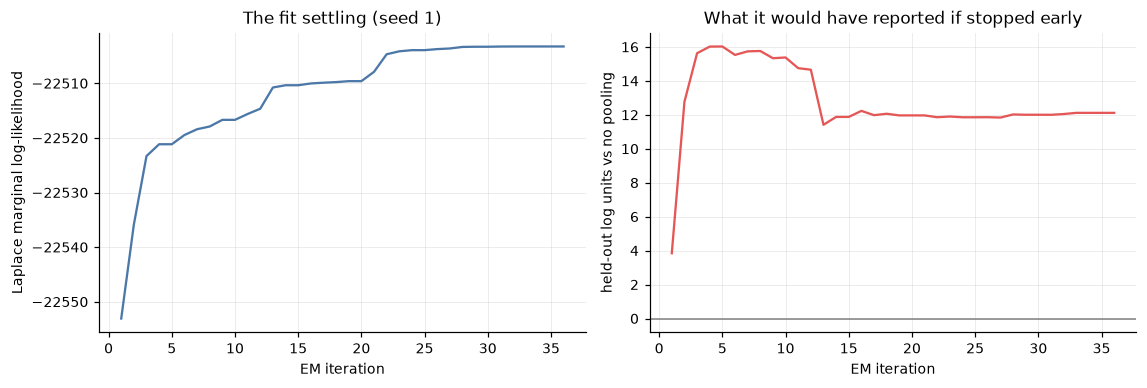

In [11]:
TR = pd.read_csv(os.path.join(RES, 'seed1', 'joint_trace.csv'))
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax[0].plot(TR.iteration, TR.marginal, color='#4c78a8')
ax[0].set(xlabel='EM iteration', ylabel='Laplace marginal log-likelihood',
          title='The fit settling (seed 1)')
ax[1].axhline(0, color='0.5', lw=1)
ax[1].plot(TR.iteration, TR.held_out_vs_no_pooling, color='#e45756')
ax[1].set(xlabel='EM iteration', ylabel='held-out log units vs no pooling',
          title='What it would have reported if stopped early')
fig.tight_layout()
print(f'first recorded {TR.held_out_vs_no_pooling.iloc[0]:+.1f}, '
      f'peak {TR.held_out_vs_no_pooling.max():+.1f}, '
      f'converged {TR.held_out_vs_no_pooling.iloc[-1]:+.1f}')

The held-out figure starts at $+3.8$, climbs to $+16.0$ by the fifth iteration,
and comes down to $+12.1$ where it stays -- and the marginal is still visibly climbing while it
does. A run stopped at iteration 5 would have reported **+16.0**, a third too large.
Seed 0 does the same thing more quietly -- its trace, which was only switched on
at its twenty-first iteration, drifts from $+5.4$ down to $+4.1$.

There is no way to notice that from a single fit, which is why the trace is
recorded at every iteration rather than at the end. It costs seventeen likelihood
evaluations against the seven thousand each iteration already spends.

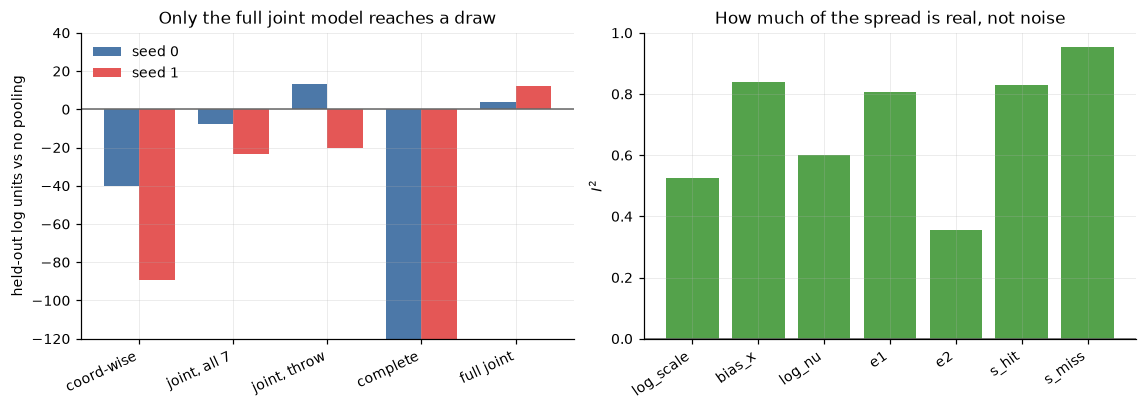

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
w = 0.38
allrows = rows + [('full joint', gain(JT), gain(JT1))]
x = np.arange(len(allrows))
ax[0].axhline(0, color='0.4', lw=1)
ax[0].bar(x - w / 2, [r[1] for r in allrows], w, color='#4c78a8', label='seed 0')
ax[0].bar(x + w / 2, [r[2] for r in allrows], w, color='#e45756', label='seed 1')
ax[0].set_xticks(x, ['coord-wise', 'joint, all 7', 'joint, throw', 'complete',
                     'full joint'], rotation=25, ha='right')
ax[0].set(ylabel='held-out log units vs no pooling', ylim=(-120, 40),
          title='Only the full joint model reaches a draw')
ax[0].legend()

ax[1].axhline(0, color='0.4', lw=1)
ax[1].bar(np.arange(len(PARAMS)), het.I2, color='#54a24b')
ax[1].set_xticks(np.arange(len(PARAMS)),
                 [p.replace('logit_', '').replace('_minus_2', '') for p in PARAMS],
                 rotation=35, ha='right')
ax[1].set(ylabel=r'$I^2$', ylim=(0, 1),
          title='How much of the spread is real, not noise')
fig.tight_layout()

## Conclusion

**Fit each player separately -- but the reason is not the one section 3
suggested.**

Every *approximate* form of partial pooling loses, and loses badly:
coordinate-wise by 40 and 89 log units on two independent splits, the two-stage
joint fit by 8 and 23, complete pooling by around 360. Fitting the hierarchical
model itself -- no summaries, no collapsing a player to a mean and a curvature --
gains 4.1 and 12.2. So most of what looked like a verdict on pooling was a
verdict on how it was being computed.

**And then the real answer is a draw.** Ten of seventeen players improve on both
splits, $p = 0.63$; the median player gains under 0.2 log units; and seed 1's
$+12.2$ becomes $-8.2$ if one player is removed. There is no broad effect here in
either direction.

**What partial pooling does buy is repair.** The gains are concentrated on
players whose own fit had fallen over -- $\nu$ pinned against its lower clip, no
usable covariance, five of seventeen on one split and six on the other. The joint
model has no trouble with them, because the curvature it needs is
$-\nabla^2 L_p + T^{-1}$ rather than $-\nabla^2 L_p$, and it pulls their $\nu$
back inside the range. That is a real and narrow benefit: use it when a player's
individual fit is degenerate, not to improve players who already have one.

**Two diagnostics worth more than the answer.** Coordinate-wise shrinkage failed
*worst on the players with the least data*, backwards from everything shrinkage
is meant to do, because the parameters are strongly correlated across players
(core scale against elongation, $-0.745$) and pulling each toward its own mean
drags the vector off the ridge they lie on. And the single positive number in the
two-stage sections, $+13.2$, came from choosing among five variants by their
held-out score and did not survive a fresh split -- held-out likelihood is no
defence against overfitting if you use it to pick the model.

**A third, about the fitting itself.** The held-out figure moves while the EM is
still settling: seed 1 peaks at $+16.0$ on its fifth iteration on the way to
$+12.1$, and seed 0 is still drifting from $+5.4$ to $+4.1$ over its last forty.
The early numbers are the flattering ones, and neither is real.

**What this licenses.** Notebooks 21, 24 and 25 all fit players independently and
report per-player numbers, and that was the right call -- not because pooling
hurts, but because it does not help. It also prices the alternative the rest of
the project uses: complete pooling across seventeen professionals costs 0.067 a
visit, a tenth of the entire Gaussian-to-Student-t gain, so the ability bands are
a useful summary and not a player.

**What is still open.** Seventeen units is few: a $7\times 7$ population
covariance is 28 numbers, and the tests for `darts.hierarchical` put the power to
detect a moderate $\tau = 0.3$ at about 62%. The case pooling exists for -- a
player with *little* data -- is also untested here, because every player in this
set has two hundred visits or more. Both point the same way: rerun this at a
lower visit threshold, with a hundred players, most of them badly measured. That
is where a hierarchical model should earn its keep, and nothing here says it
would not.